# Defensive Patterns: Teams That Concede Fewer Goals Than Average

**Analytics Cup 2.0 — Football, Defensive Positioning**

Research question: **does the sample of teams that concede fewer goals than average show a
distinct defensive pattern — and is it about how *much* they defend, or *how* they defend?**

Follows on from [`01_exploratory_analysis.ipynb`](01_exploratory_analysis.ipynb), where the naive
"compact block ⇒ fewer shots" hypothesis turned out to be confounded by pitch zone/phase type.
Here the unit of comparison shifts from individual phases to **teams**, using every defensive
phase and event in the 20-match sample to build a per-team feature table.


## 1. Defining the two groups

Important caveat up front: this dataset has only 20 matches across 13 teams, so most teams
have just 1–4 games. Team-level goals conceded is a noisy, small-sample statistic — a single
deflected shot changes a team's rate a lot. We keep this analysis **descriptive/correlational**,
report exact team sample sizes throughout, and stress-test every finding with a leave-one-team-out
check before trusting it.

In [1]:
import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "../../skillcorner-opendata/data/matches"
match_dirs = sorted(glob.glob(f"{DATA_DIR}/*"))
MATCH_IDS = [d.replace("\\", "/").split("/")[-1] for d in match_dirs]

match_meta = {}
team_names = {}
for mid in MATCH_IDS:
    with open(f"{DATA_DIR}/{mid}/{mid}_match.json", encoding="utf-8") as f:
        m = json.load(f)
    home_id, away_id = m["home_team"]["id"], m["away_team"]["id"]
    match_meta[mid] = {
        "home_id": home_id, "away_id": away_id,
        "home_name": m["home_team"]["short_name"], "away_name": m["away_team"]["short_name"],
        "home_score": m["home_team_score"], "away_score": m["away_team_score"],
    }
    team_names[home_id] = m["home_team"]["short_name"]
    team_names[away_id] = m["away_team"]["short_name"]


In [2]:
records = []
for mid, mm in match_meta.items():
    records.append({"team": mm["home_name"], "match_id": mid, "conceded": mm["away_score"], "scored": mm["home_score"]})
    records.append({"team": mm["away_name"], "match_id": mid, "conceded": mm["home_score"], "scored": mm["away_score"]})
team_games = pd.DataFrame(records)

league_avg_conceded = team_games["conceded"].mean()

team_summary = team_games.groupby("team").agg(
    n_games=("match_id", "size"),
    goals_conceded=("conceded", "sum"),
    goals_scored=("scored", "sum"),
)
team_summary["conceded_per_game"] = team_summary["goals_conceded"] / team_summary["n_games"]
team_summary["scored_per_game"] = team_summary["goals_scored"] / team_summary["n_games"]
team_summary["group"] = np.where(team_summary["conceded_per_game"] < league_avg_conceded, "low_concede", "high_concede")

print(f"League-average conceded/game in this sample: {league_avg_conceded:.2f}")
team_summary.sort_values("conceded_per_game")


League-average conceded/game in this sample: 1.65


,n_games,goals_conceded,goals_scored,conceded_per_game,scored_per_game,group
team,,,,,,
Melbourne City,3,1,4,0.333333,1.333333,low_concede
Sydney FC,2,2,4,1.000000,2.000000,low_concede
Western Sydney,2,2,4,1.000000,2.000000,low_concede
Auckland FC,7,8,12,1.142857,1.714286,low_concede
Perth Glory,2,3,2,1.500000,1.000000,low_concede
Brisbane FC,3,5,5,1.666667,1.666667,high_concede
Melbourne V FC,4,7,9,1.750000,2.250000,high_concede
CC Mariners,4,7,3,1.750000,0.750000,high_concede
Western United,4,7,12,1.750000,3.000000,high_concede


13 teams, 1–7 games each (Auckland FC is the only one with a genuinely useful sample size at 7).
This is why the primary analysis below treats `conceded_per_game` as a **continuous** variable
(Spearman correlation across all 13 teams) rather than only comparing two small groups — it uses
the ranking information in the full sample instead of throwing it away at a single threshold.
The low/high split is kept as a readable label for plots, not as the statistical test itself.

## 2. Building team-level defensive features

Every defensive phase, engagement, and defended touch in the 20 matches, aggregated to one row per team. Three data sources, three different join keys:

In [3]:
cols_dyn = [
    "match_id", "event_type", "event_subtype", "team_id",
    "xloss_player_possession_start", "xloss_player_possession_end",
    "organised_defense", "defensive_structure", "n_defensive_lines",
    "last_defensive_line_height_start", "overall_pressure_start",
]

phase_frames, engagement_frames, possession_frames = [], [], []
for mid in MATCH_IDS:
    mm = match_meta[mid]
    other_team = {mm["home_id"]: mm["away_id"], mm["away_id"]: mm["home_id"]}

    # phases_of_play: defending team = whoever is NOT team_in_possession
    ph = pd.read_csv(f"{DATA_DIR}/{mid}/{mid}_phases_of_play.csv")
    ph["defending_team"] = ph["team_in_possession_id"].map(other_team).map(team_names)
    ph["match_id"] = mid
    phase_frames.append(ph)

    dyn = pd.read_csv(f"{DATA_DIR}/{mid}/{mid}_dynamic_events.csv", usecols=lambda c: c in cols_dyn, low_memory=False)
    dyn["match_id"] = mid

    # on_ball_engagement: team_id is the PRESSING (defending) player's team directly
    obe = dyn[dyn["event_type"] == "on_ball_engagement"].copy()
    obe["defending_team"] = obe["team_id"].map(team_names)
    engagement_frames.append(obe)

    # player_possession: team_id is the ATTACKER's team -> defending team is the other one
    pp = dyn[dyn["event_type"] == "player_possession"].copy()
    pp["defending_team"] = pp["team_id"].map(other_team).map(team_names)
    possession_frames.append(pp)

phases = pd.concat(phase_frames, ignore_index=True)
engagements = pd.concat(engagement_frames, ignore_index=True)
possessions = pd.concat(possession_frames, ignore_index=True)
print(f"phases: {len(phases)}  |  on_ball_engagement: {len(engagements)}  |  defended touches: {len(possessions)}")


phases: 8834  |  on_ball_engagement: 17445  |  defended touches: 18710


In [4]:
# --- (a) block shape, from phases_of_play ---
phases["def_area_end"] = phases["team_out_of_possession_width_end"] * phases["team_out_of_possession_length_end"]
block_share = (
    phases.groupby("defending_team")["team_out_of_possession_phase_type"]
    .value_counts(normalize=True).unstack(fill_value=0)
    .add_prefix("block_share_")
)
mb_area = (
    phases[phases["team_out_of_possession_phase_type"] == "medium_block"]
    .groupby("defending_team")["def_area_end"].mean()
    .rename("mean_def_area_medium_block")
)

# --- (b) pressing, from on_ball_engagement ---
engagements["xloss_delta"] = engagements["xloss_player_possession_end"] - engagements["xloss_player_possession_start"]
n_opponent_touches = possessions.groupby("defending_team").size().rename("n_opponent_touches")
press = engagements.groupby("defending_team").agg(
    n_engagements=("event_subtype", "size"),
    mean_xloss_delta_caused=("xloss_delta", "mean"),
    share_pressing=("event_subtype", lambda s: (s == "pressing").mean()),
    share_counter_press=("event_subtype", lambda s: (s == "counter_press").mean()),
    share_recovery_press=("event_subtype", lambda s: (s == "recovery_press").mean()),
).join(n_opponent_touches)
press["engagements_per_100_opp_touches"] = 100 * press["n_engagements"] / press["n_opponent_touches"]

# --- (c) defensive organisation, from the attacker's perspective on player_possession rows ---
possessions["organised_defense"] = possessions["organised_defense"].astype(float)
shape = possessions.groupby("defending_team").agg(
    organised_defense_rate=("organised_defense", "mean"),
    mean_n_defensive_lines=("n_defensive_lines", "mean"),
    mean_last_line_height=("last_defensive_line_height_start", "mean"),
)
shape["share_high_pressure_applied"] = (
    possessions.groupby("defending_team")["overall_pressure_start"]
    .apply(lambda s: s.isin(["high_pressure", "very_high_pressure"]).mean())
)

team_features = (
    team_summary
    .join(block_share)
    .join(mb_area)
    .join(press)
    .join(shape)
)
team_features.round(3)


,n_games,goals_conceded,goals_scored,conceded_per_game,scored_per_game,group,block_share_chaotic,block_share_defending_direct,block_share_defending_quick_break,block_share_defending_set_play,block_share_defending_transition,block_share_high_block,block_share_low_block,block_share_medium_block,mean_def_area_medium_block,n_engagements,mean_xloss_delta_caused,share_pressing,share_counter_press,share_recovery_press,n_opponent_touches,engagements_per_100_opp_touches,organised_defense_rate,mean_n_defensive_lines,mean_last_line_height,share_high_pressure_applied
team,,,,,,,,,,,,,,,,,,,,,,,,,,
Adelaide United,3,9,6,3.000,2.000,high_concede,0.235,0.061,0.006,0.042,0.027,0.137,0.177,0.314,1939.355,1364,-0.022,0.174,0.084,0.266,1354,100.739,0.536,2.794,32.868,0.230
Auckland FC,7,8,12,1.143,1.714,low_concede,0.218,0.083,0.007,0.034,0.024,0.151,0.155,0.328,1859.244,3016,-0.024,0.234,0.105,0.238,3061,98.530,0.602,2.803,36.178,0.251
Brisbane FC,3,5,5,1.667,1.667,high_concede,0.177,0.088,0.015,0.027,0.018,0.143,0.195,0.338,1798.046,1224,-0.027,0.237,0.092,0.244,1403,87.242,0.631,2.874,33.290,0.192
CC Mariners,4,7,3,1.750,0.750,high_concede,0.157,0.068,0.014,0.048,0.022,0.104,0.231,0.356,1835.725,1805,-0.027,0.217,0.070,0.213,2281,79.132,0.743,2.495,30.243,0.163
Macarthur FC,2,4,1,2.000,0.500,high_concede,0.192,0.064,0.014,0.059,0.014,0.103,0.222,0.332,1903.484,911,-0.025,0.201,0.095,0.215,987,92.300,0.618,2.661,30.608,0.188
Melbourne City,3,1,4,0.333,1.333,low_concede,0.213,0.120,0.005,0.033,0.021,0.197,0.100,0.310,1918.838,1080,-0.026,0.335,0.124,0.198,1081,99.907,0.644,2.829,38.326,0.233
Melbourne V FC,4,7,9,1.750,2.250,high_concede,0.265,0.068,0.011,0.044,0.033,0.141,0.163,0.274,1831.415,1470,-0.019,0.188,0.118,0.248,1529,96.141,0.495,2.783,35.175,0.278
Newcastle,1,2,0,2.000,0.000,high_concede,0.168,0.059,0.017,0.071,0.004,0.105,0.252,0.324,1766.620,508,-0.020,0.201,0.065,0.215,533,95.310,0.571,2.853,28.882,0.206
Perth Glory,2,3,2,1.500,1.000,low_concede,0.194,0.084,0.013,0.043,0.006,0.123,0.216,0.320,1772.620,999,-0.034,0.194,0.062,0.219,1107,90.244,0.617,2.897,29.838,0.173


## 3. Which features actually track goals conceded?

Spearman rank correlation of every feature against `conceded_per_game` across all 13 teams (monotonic, robust to the small-n / non-normal distributions here), plus a same-direction Mann-Whitney check between the two labelled groups for reference.

In [5]:
feature_cols = [c for c in team_features.columns if c not in ["n_games", "goals_conceded", "goals_scored", "conceded_per_game", "scored_per_game", "group"]]

rows = []
for c in feature_cols:
    rho, p = stats.spearmanr(team_features["conceded_per_game"], team_features[c])
    low = team_features.loc[team_features["group"] == "low_concede", c]
    high = team_features.loc[team_features["group"] == "high_concede", c]
    _, p_mw = stats.mannwhitneyu(low, high, alternative="two-sided")
    rows.append({"feature": c, "spearman_rho": rho, "spearman_p": p, "low_concede_mean": low.mean(), "high_concede_mean": high.mean(), "mannwhitney_p": p_mw})

results = pd.DataFrame(rows).sort_values("spearman_p").reset_index(drop=True)
results.round(3)


,feature,spearman_rho,spearman_p,low_concede_mean,high_concede_mean,mannwhitney_p
0,share_pressing,-0.741,0.004,0.252,0.201,0.171
1,block_share_defending_direct,-0.502,0.080,0.083,0.070,0.435
2,block_share_low_block,0.466,0.108,0.170,0.204,0.222
3,block_share_high_block,-0.444,0.129,0.150,0.123,0.284
4,mean_last_line_height,-0.427,0.145,34.347,32.035,0.435
5,share_recovery_press,0.419,0.154,0.221,0.237,0.284
6,share_counter_press,-0.416,0.157,0.097,0.088,0.524
7,organised_defense_rate,-0.361,0.226,0.626,0.601,0.724
8,block_share_defending_set_play,0.302,0.315,0.041,0.045,0.724
9,mean_def_area_medium_block,0.247,0.416,1838.141,1855.928,0.833


**`share_pressing`** — the share of a team's defensive engagements that are proactive,
organised `pressing` (as opposed to `counter_press`/`recovery_press`, which fire *after* the ball
is already lost, i.e. reactive scrambling) — stands well clear of everything else:
Spearman ρ ≈ −0.74, p ≈ 0.004 across all 13 teams.

Two things worth noticing before getting excited:

- **It is not about volume.** `engagements_per_100_opp_touches` (how *often* a team engages the
  ball carrier at all) has essentially zero correlation with goals conceded. Teams don't concede
  less because they defend "more" — they concede less when a larger share of that defending is
  proactive rather than reactive.
- Block-shape signals from the first notebook (`block_share_high_block` negative,
  `block_share_low_block` positive) point the same direction but are individually weak
  (p ≈ 0.08–0.13) — consistent supporting context, not a second independent finding.


## 4. Stress-testing the main finding

With n=13 teams a single team could be driving the whole correlation. Two checks: leave-one-team-out stability, and whether this is really a *defensive* signal or just a proxy for "generally good team" (which would also score more goals).

In [6]:
x, y = team_features["share_pressing"], team_features["conceded_per_game"]
rho_full, p_full = stats.spearmanr(y, x)
print(f"Full sample (n=13): rho={rho_full:.3f}, p={p_full:.4f}\n")

loo = []
for team in team_features.index:
    sub = team_features.drop(team)
    rho, p = stats.spearmanr(sub["conceded_per_game"], sub["share_pressing"])
    loo.append({"dropped_team": team, "n_games_of_dropped_team": team_features.loc[team, "n_games"], "rho": rho, "p": p})
loo_df = pd.DataFrame(loo).sort_values("rho")
print("Leave-one-team-out (does the correlation survive removing any single team?):")
loo_df.round(3)


Full sample (n=13): rho=-0.741, p=0.0038

Leave-one-team-out (does the correlation survive removing any single team?):


,dropped_team,n_games_of_dropped_team,rho,p
8,Perth Glory,2,-0.832,0.001
12,Western United,4,-0.792,0.002
11,Western Sydney,2,-0.784,0.003
3,CC Mariners,4,-0.768,0.004
2,Brisbane FC,3,-0.765,0.004
1,Auckland FC,7,-0.743,0.006
6,Melbourne V FC,4,-0.743,0.006
7,Newcastle,1,-0.735,0.006
4,Macarthur FC,2,-0.735,0.006
9,Sydney FC,2,-0.686,0.014


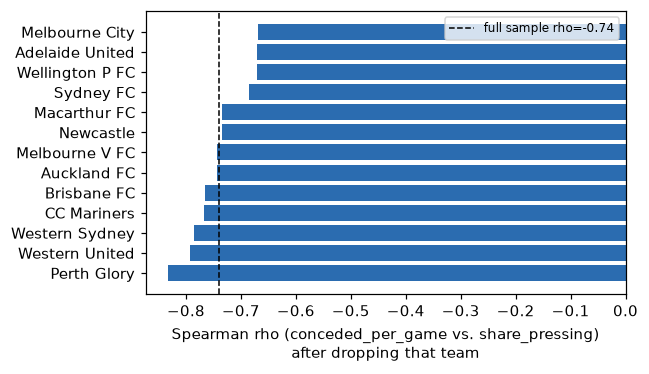

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(loo_df["dropped_team"], loo_df["rho"], color="#2b6cb0")
ax.axvline(rho_full, color="black", linestyle="--", linewidth=1, label=f"full sample rho={rho_full:.2f}")
ax.set_xlabel("Spearman rho (conceded_per_game vs. share_pressing)\nafter dropping that team")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Correlation stays in the −0.67 to −0.83 range no matter which team is dropped, and stays significant (p < 0.02) every time — it isn't an artefact of Auckland FC's larger sample or any single outlier.

In [8]:
rho_offense, p_offense = stats.spearmanr(team_features["share_pressing"], team_features["scored_per_game"])
print(f"share_pressing vs. goals SCORED per game: rho={rho_offense:.3f}, p={p_offense:.3f}")
print("(if this were also strongly correlated, share_pressing might just be a proxy for")
print(" 'generally good/dominant team' rather than a specifically defensive pattern)")


share_pressing vs. goals SCORED per game: rho=0.122, p=0.692
(if this were also strongly correlated, share_pressing might just be a proxy for
 'generally good/dominant team' rather than a specifically defensive pattern)


`share_pressing` has essentially no relationship with a team's own scoring rate (ρ ≈ 0.12, p ≈ 0.69) — it tracks defensive outcomes specifically, not general team quality or dominance.

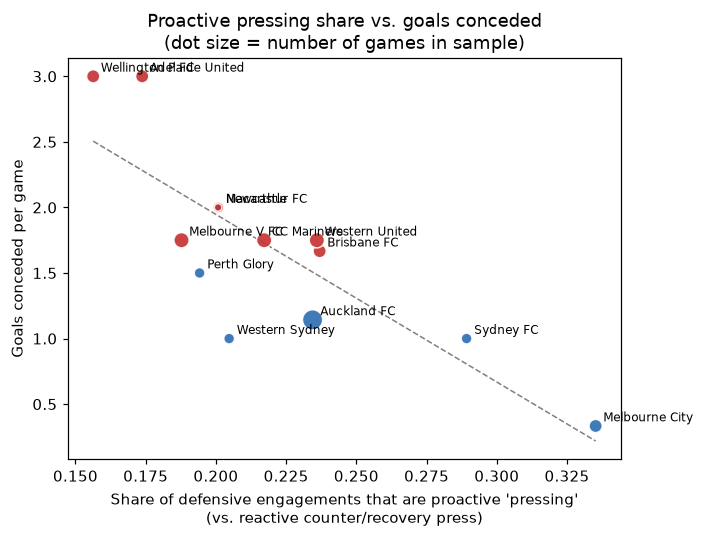

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5))
colors = team_features["group"].map({"low_concede": "#2b6cb0", "high_concede": "#c53030"})
ax.scatter(team_features["share_pressing"], team_features["conceded_per_game"],
           s=team_features["n_games"] * 25, c=colors, edgecolors="white", zorder=3, alpha=0.9)

for team, row in team_features.iterrows():
    ax.annotate(team, (row["share_pressing"], row["conceded_per_game"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)

z = np.polyfit(team_features["share_pressing"], team_features["conceded_per_game"], 1)
xs = np.linspace(team_features["share_pressing"].min(), team_features["share_pressing"].max(), 50)
ax.plot(xs, np.polyval(z, xs), "--", color="gray", linewidth=1, zorder=1)

ax.set_xlabel("Share of defensive engagements that are proactive 'pressing'\n(vs. reactive counter/recovery press)")
ax.set_ylabel("Goals conceded per game")
ax.set_title("Proactive pressing share vs. goals conceded\n(dot size = number of games in sample)")
plt.tight_layout()
plt.show()


## 5. Summary and proposed research question for the final submission

**Finding:** in this 20-match sample, teams that concede fewer goals than average are
distinguished less by *how much* they engage the ball carrier, and more by *when* — a higher
share of their defensive engagements are organised, proactive pressing rather than reactive
scrambling after losing the ball. The signal is specific to defensive outcomes (not a stand-in
for "good team" more broadly) and survives removing any single team from the sample.

**Proposed question for the final entry:**
*"Does proactive, organised pressing — as opposed to pressing volume or reactive recovery
actions — distinguish teams that concede fewer goals, and can this be identified from a team's
in-match defensive-engagement signature alone?"*

This is deliberately narrower and more testable than "find a defensive pattern": it makes a
specific, falsifiable claim (organisation > volume), it's already grounded in real numbers from
this dataset, and it gives a coach something concrete to act on — track the *proactive share* of
your pressing actions, not just how many you make.

### What's still needed before this is submission-ready

1. **More rigor than pairwise correlation.** A small multivariate model (e.g. `conceded_per_game`
   or shot-conceded-rate regressed on `share_pressing` + block-shape controls) to check the effect
   holds once other factors are accounted for, and whether it explains variance beyond what phase
   type/pitch zone (Notebook 1's confound) already predicts.
2. **A phase-level version of the same test.** Right now this is team-season level (n=13). The
   same "proactive vs. reactive" distinction can likely be tested at the possession-phase level
   (does a phase entered via `pressing` lead to fewer/less dangerous opponent outcomes than one
   entered via `counter_press`?) — much larger n, addresses the small-sample concern directly.
3. **A concrete visual/example.** Pull 2–3 tracking clips of a clear "proactive pressing" sequence
   vs. a "reactive scramble" sequence (using the `pressing_chain` field) to illustrate the
   difference visually for the 1-minute pitch video and the README figures.
4. **Explicit limitations section in the final README**: 20 matches / 13 teams / one league,
   correlational not causal, and the reverse-causality caveat (teams that already defend well for
   other reasons — e.g. a strong back line — may simply have more opportunities to press proactively
   because they're rarely under duress themselves).
